In [1]:
import os
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(BASE_DIR)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from src.data_handling.dataset import ECGDataset
import torch
from src.model import (
    ECGAutoencoder,
    TransformerAutoencoder
)
from torch.utils.data import DataLoader

In [18]:
ROOT_DIR = os.path.join(BASE_DIR, '..')
DATA_DIR =  os.path.join(ROOT_DIR, 'Data')

0    1011
1    1011
2    1011
3    1011
4    1011
Name: 'V5', dtype: int64


<Axes: xlabel="'sample #'">

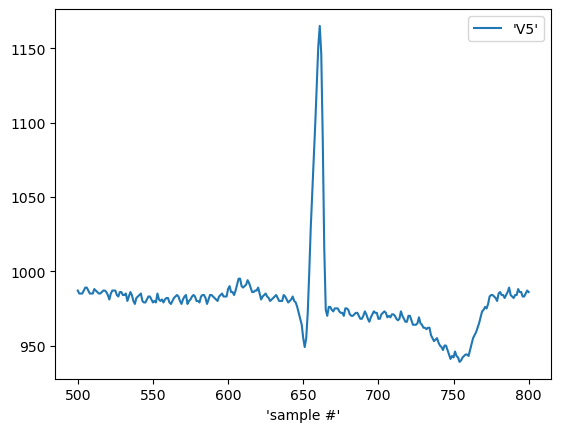

In [19]:
file_path = os.path.join(DATA_DIR, 'mitbih_database', '100.csv')

df = pd.read_csv(file_path)

print(df['\'V5\''].head())

df.loc[500:800].plot(x = '\'sample #\'',y='\'V5\'')

In [20]:
import matplotlib.pyplot as plt

def plot_ecg_window(x, leads=None, title=None):
    """
    x: torch.Tensor or np.ndarray, shape (n_channels, window_size)
    leads: list of lead names for labeling
    """
    if isinstance(x, torch.Tensor):
        x = x.numpy()

    n_channels, window_size = x.shape
    time = np.arange(window_size)

    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 2*n_channels), sharex=True)

    if n_channels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(time, x[i], linewidth=1)
        if leads:
            ax.set_ylabel(leads[i])
        ax.grid(True, linestyle="--", alpha=0.5)

    axes[-1].set_xlabel("Samples")
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [44]:
preprocessed_data_dir = os.path.join(DATA_DIR, 'input', 'preprocessed_data',"fs250_bp0.5-45Hz")
json_split_path = os.path.join(DATA_DIR, 'input', 'experiment', 'leads_MLII_V1_tst0.25_rd42.json')

# Double channel (MLII + V1)
ds2 = ECGDataset(preprocessed_data_dir, window_size=1000,  json_file_path=json_split_path, mode="sliding", split='test')


Loading data for 8 patients from 'test' split...


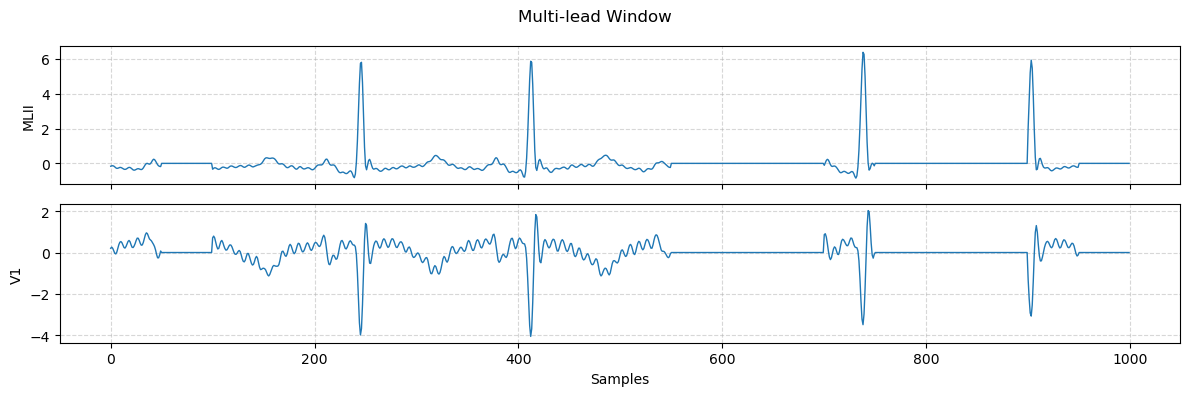

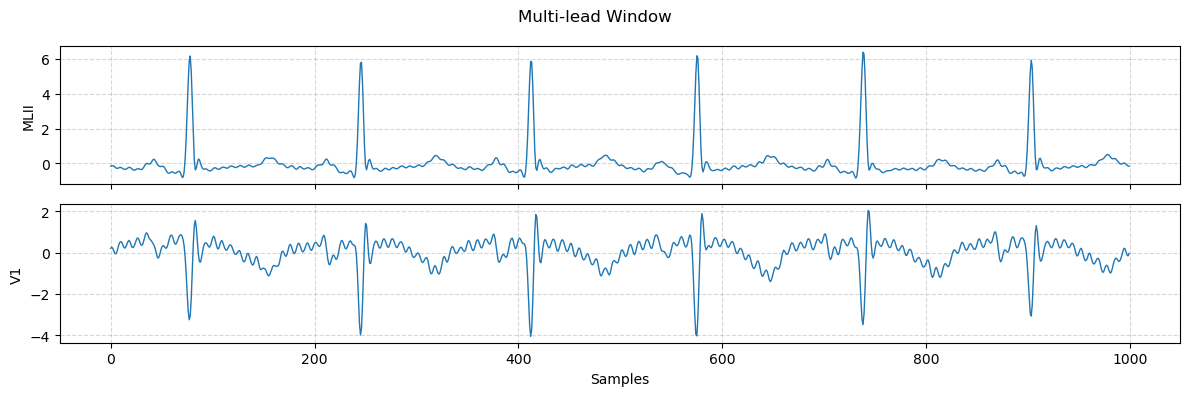

In [45]:
x, y = ds2[50]

plot_ecg_window(x, leads=["MLII", "V1"], title="Multi-lead Window")

plot_ecg_window(y, leads=["MLII", "V1"], title="Multi-lead Window")



Loading data for 24 patients from 'train' split...


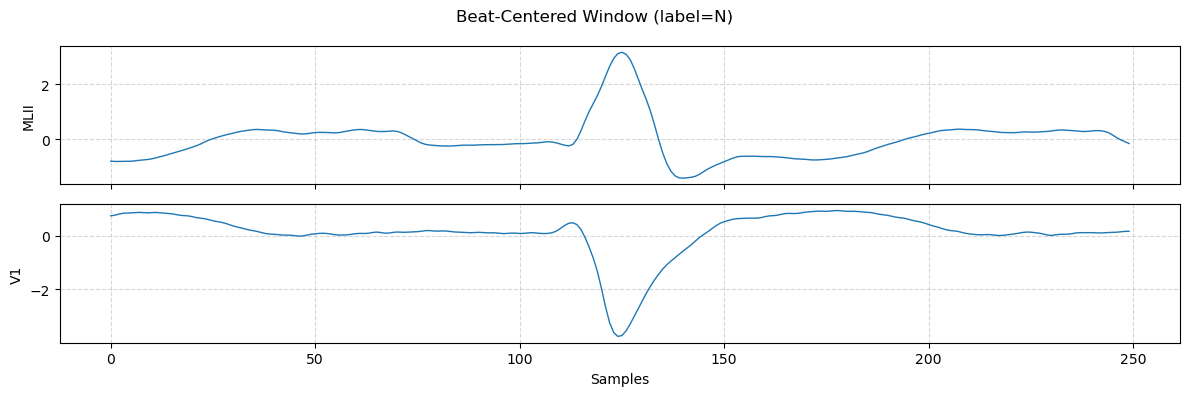

In [46]:
ds3 = ECGDataset(preprocessed_data_dir, window_size=250,  json_file_path=json_split_path, mode="beat")
x, y = ds3[100]

plot_ecg_window(x, leads=["MLII", "V1"], title=f"Beat-Centered Window (label={y})")


In [47]:
model_path = os.path.join(DATA_DIR, 'output', 'ecg_encoder.pth')
# autoencoder = TransformerAutoencoder(in_channels=2, emb_size=32, patch_size=10, num_layers=1, nhead=2)
autoencoder = ECGAutoencoder(in_channels=2, latent_dim=64)
autoencoder_random = ECGAutoencoder(in_channels=2, latent_dim=64)


autoencoder.load_state_dict(torch.load(model_path))
autoencoder.eval()

ECGAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(2, 16, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (3): ReLU()
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (3): ReLU()
    (4): ConvTranspose1d(16, 2, kernel_size=(7,), stride=(2,), padding=(3,), output_padding=(1,))
  )
)

In [48]:
ssl_loader = DataLoader(ds2, batch_size=16)
signals, labels = next(iter(ssl_loader))  # shape: [B, C, T]
with torch.no_grad():
    reconstructed_signals, _ = autoencoder(signals)  # shape: [B, C, T]
    reconstructed_signals2, _ = autoencoder(labels)  # shape: [B, C, T]
    reconstructed_signals3, _ = autoencoder_random(labels)  # shape: [B, C, T]

In [49]:
print(reconstructed_signals.shape)

torch.Size([16, 2, 1000])


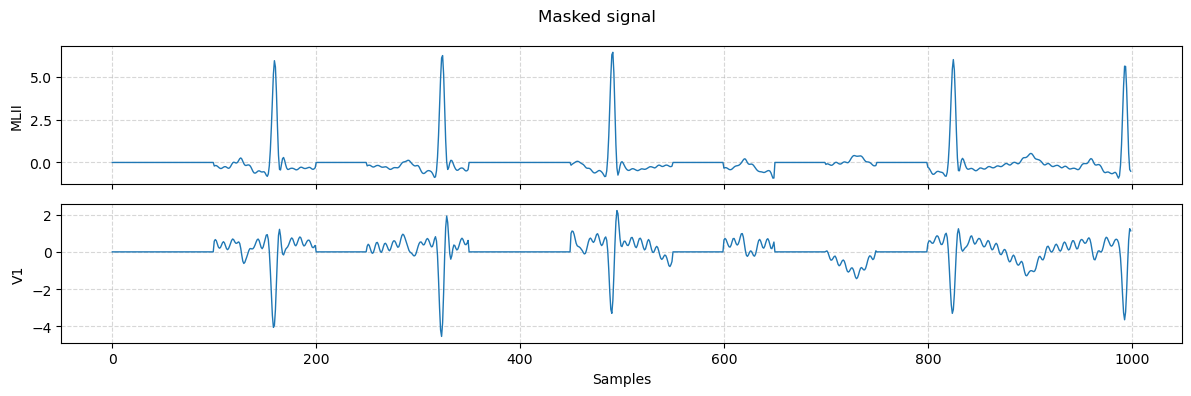

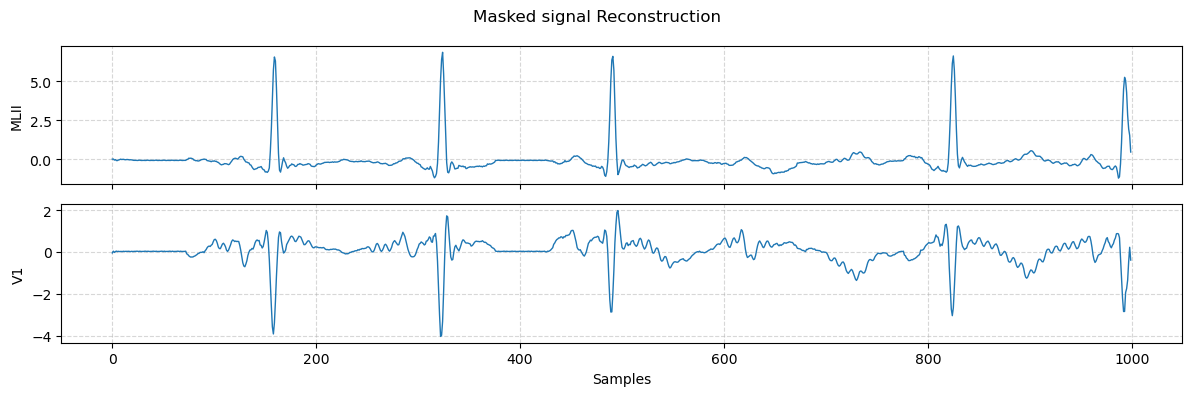

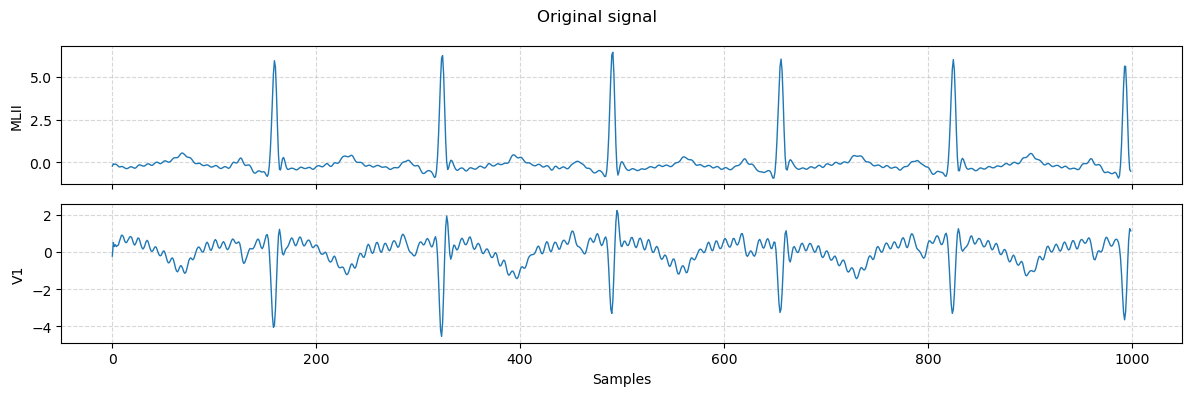

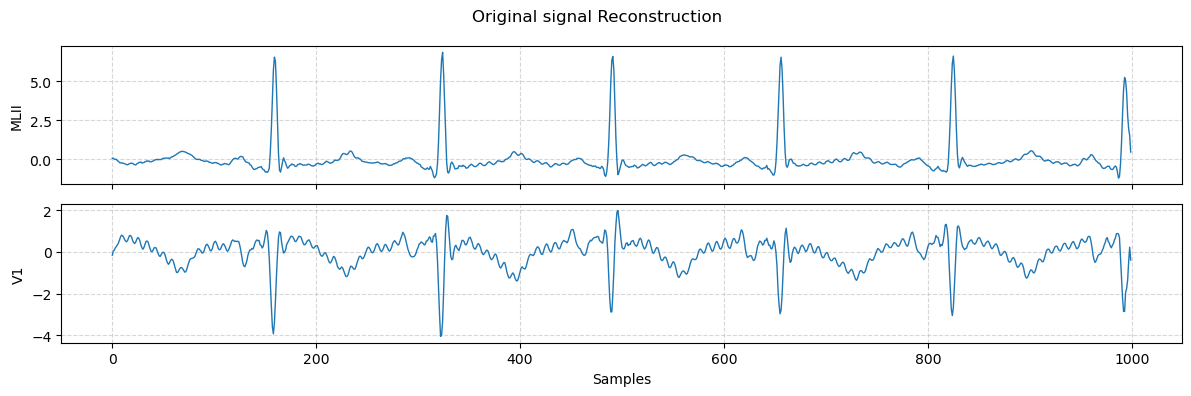

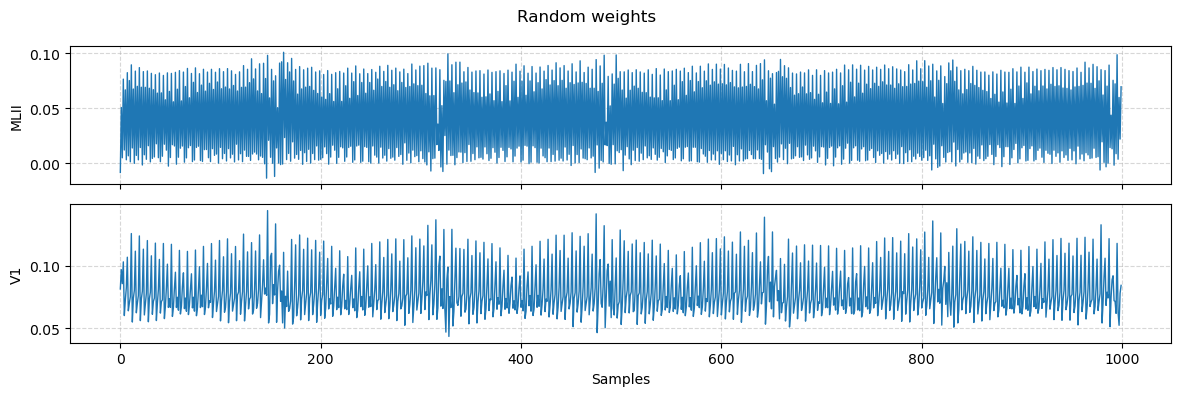

In [50]:
plot_ecg_window(signals[0], leads=["MLII", "V1"], title="Masked signal")
plot_ecg_window(reconstructed_signals[0], leads=["MLII", "V1"], title="Masked signal Reconstruction")
plot_ecg_window(labels[0], leads=["MLII", "V1"], title="Original signal")
plot_ecg_window(reconstructed_signals2[0], leads=["MLII", "V1"], title="Original signal Reconstruction")
plot_ecg_window(reconstructed_signals3[0], leads=["MLII", "V1"], title="Random weights")

